# B题：红酒质量预测

本 Notebook 按题目给出的 B 题数据划分完成红酒质量预测实验。

- 数据：winequality-red.csv，共 1599 个样本、11 个理化特征和 quality 标签。
- 划分：前 1300 个样本作为训练集，后 299 个样本作为测试集；测试集不参与模型选择和调参。
- 方法：比较多数类基线、逻辑回归、支持向量机、随机森林、极端随机树、梯度提升树，并使用 5 折分层交叉验证。
- 特征：使用 ANOVA F 检验进行特征选择，并用 PCA 作为一种特征提取方案参与模型比较。
- 评价：同时报告 accuracy、balanced accuracy、macro-F1、weighted-F1 和 MAE；由于质量等级分布不均衡，以 macro-F1 作为调参主指标。

数据集参考：附件 winequality.names 要求引用 Cortez 等人的工作：P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis, “Modeling wine preferences by data mining from physicochemical properties”, Decision Support Systems, 47(4):547–553, 2009。



## 实验流程

1. 读取并核验数据格式、字段、样本数、缺失值和标签分布。
2. 按题目要求固定切分训练集和测试集。
3. 仅使用训练集拟合标准化、特征选择和 PCA，避免测试集信息泄漏。
4. 用训练集上的 5 折分层交叉验证比较模型。
5. 对极端随机树 + SelectKBest 进行网格调参，并用 macro-F1 选择最优参数。
6. 在完整的 1300 条训练数据上重训最优模型，在 299 条测试数据上预测、评价并保存预测结果。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import sklearn
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    mean_absolute_error,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
N_TRAIN = 1300
N_TEST = 299
TARGET = "quality"
FEATURE_NAMES = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]


def locate_data():
    '''在 Notebook 当前目录及其上级目录中查找随实验提供的数据。'''
    current = Path.cwd().resolve()
    roots = [current, *current.parents]
    candidates = []
    for root in roots:
        candidates.extend(
            [
                root / "work" / "b_red_wine_data" / "winequality-red.csv",
                root / "b_red_wine_data" / "winequality-red.csv",
                root / "winequality-red.csv",
                root / "datasets" / "winequality-red.csv",
            ]
        )
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(
        "没有找到 winequality-red.csv。请将数据文件放在 Notebook 同目录，"
        "或放在 work/b_red_wine_data/winequality-red.csv。"
    )


DATA_PATH = locate_data()
PROJECT_ROOT = next(
    (parent for parent in [DATA_PATH.parent, *DATA_PATH.parents] if (parent / ".git").exists()),
    DATA_PATH.parent,
)
FIGURE_DIR = PROJECT_ROOT / "work" / "b_red_wine_figures"
OUTPUT_DIR = PROJECT_ROOT / "work" / "b_red_wine_outputs"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"data path: {DATA_PATH}")
print(f"figure directory: {FIGURE_DIR}")
print(f"output directory: {OUTPUT_DIR}")

pandas: 3.0.5
scikit-learn: 1.9.1
data path: /Users/wanwanzhu/yolo/work/b_red_wine_data/winequality-red.csv
figure directory: /Users/wanwanzhu/yolo/work/b_red_wine_figures
output directory: /Users/wanwanzhu/yolo/work/b_red_wine_outputs


## 1. 数据读取与基本核验

In [2]:
df = pd.read_csv(DATA_PATH, sep=";")

assert df.shape == (N_TRAIN + N_TEST, len(FEATURE_NAMES) + 1), (
    f"数据形状应为 {(N_TRAIN + N_TEST, len(FEATURE_NAMES) + 1)}，实际为 {df.shape}"
)
assert list(df.columns) == FEATURE_NAMES + [TARGET], "字段顺序或字段名称与数据说明不一致"
assert df.isna().sum().sum() == 0, "数据存在缺失值，请先检查数据文件"
assert all(pd.api.types.is_numeric_dtype(df[column]) for column in df.columns)

print(f"数据形状: {df.shape}")
print(f"标签取值: {sorted(df[TARGET].unique().tolist())}")
print(f"重复行数量: {df.duplicated().sum()}（保留重复样本，以维持题目规定的 1599 条样本和固定划分）")
display(df.head())

data_check = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "n_unique": df.nunique(),
    }
)
display(data_check)

数据形状: (1599, 12)
标签取值: [3, 4, 5, 6, 7, 8]
重复行数量: 240（保留重复样本，以维持题目规定的 1599 条样本和固定划分）


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,dtype,missing_count,n_unique
fixed acidity,float64,0,96
volatile acidity,float64,0,143
citric acid,float64,0,80
residual sugar,float64,0,91
chlorides,float64,0,153
free sulfur dioxide,float64,0,60
total sulfur dioxide,float64,0,144
density,float64,0,436
pH,float64,0,89
sulphates,float64,0,96


In [3]:
display(df[FEATURE_NAMES + [TARGET]].describe().T.round(4))

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.3196,1.7411,4.6000,7.1000,7.9000,9.2000,15.9000
volatile acidity,1599.0,0.5278,0.1791,0.1200,0.3900,0.5200,0.6400,1.5800
citric acid,1599.0,0.2710,0.1948,0.0000,0.0900,0.2600,0.4200,1.0000
residual sugar,1599.0,2.5388,1.4099,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1599.0,0.0875,0.0471,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1599.0,15.8749,10.4602,1.0000,7.0000,14.0000,21.0000,72.0000
total sulfur dioxide,1599.0,46.4678,32.8953,6.0000,22.0000,38.0000,62.0000,289.0000
density,1599.0,0.9967,0.0019,0.9901,0.9956,0.9968,0.9978,1.0037
pH,1599.0,3.3111,0.1544,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,1599.0,0.6581,0.1695,0.3300,0.5500,0.6200,0.7300,2.0000


## 2. 探索性分析与可视化

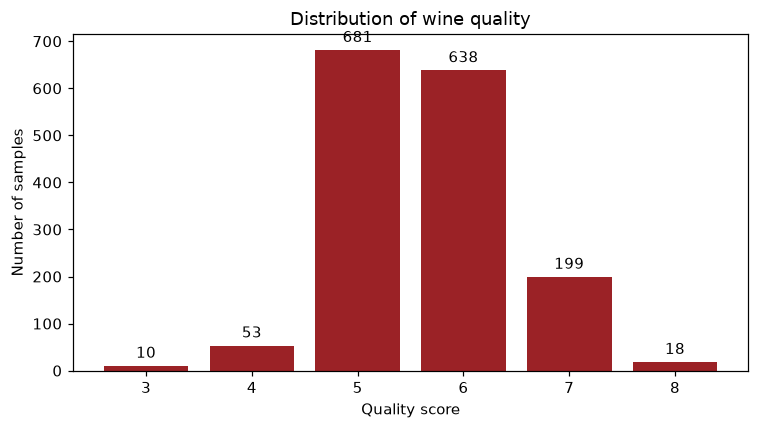

已保存: /Users/wanwanzhu/yolo/work/b_red_wine_figures/01_quality_distribution.png


In [4]:
quality_counts = df[TARGET].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(quality_counts.index.astype(str), quality_counts.values, color="#9b2226")
ax.set_title("Distribution of wine quality")
ax.set_xlabel("Quality score")
ax.set_ylabel("Number of samples")
ax.bar_label(bars, padding=3)
fig.tight_layout()
quality_fig = FIGURE_DIR / "01_quality_distribution.png"
fig.savefig(quality_fig, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"已保存: {quality_fig}")

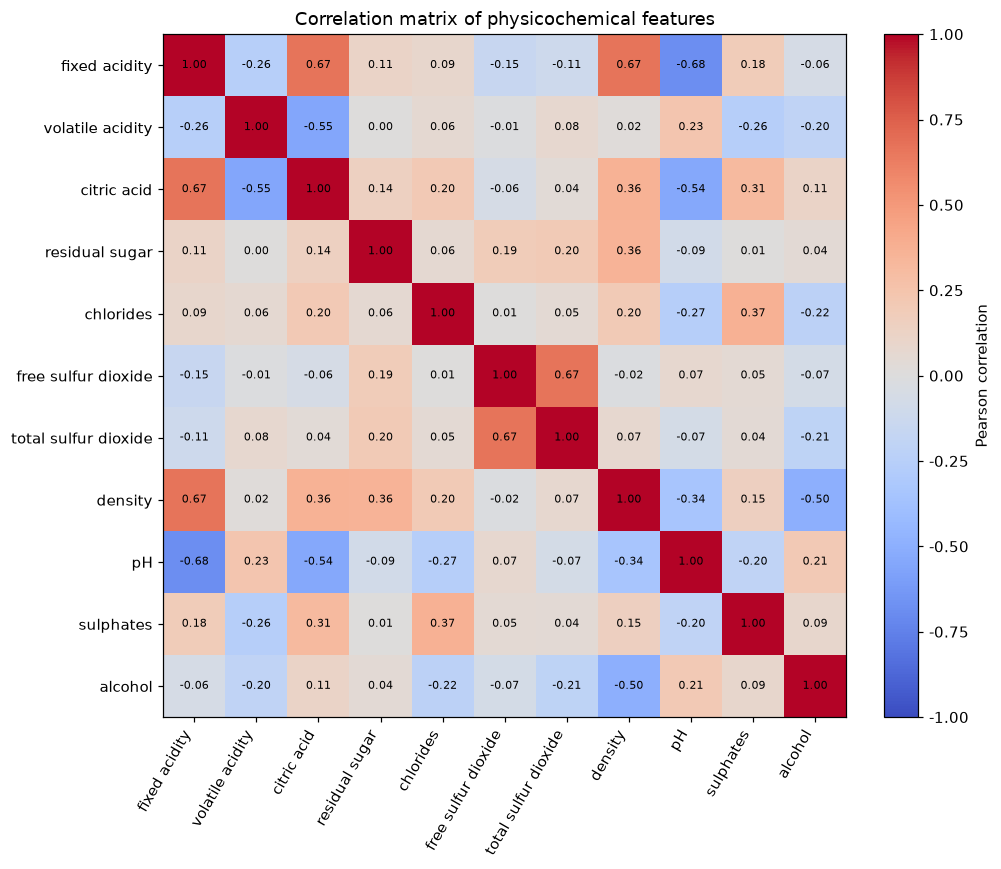

已保存: /Users/wanwanzhu/yolo/work/b_red_wine_figures/02_feature_correlation.png


In [5]:
corr = df[FEATURE_NAMES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=60, ha="right")
ax.set_yticks(range(len(FEATURE_NAMES)), FEATURE_NAMES)
ax.set_title("Correlation matrix of physicochemical features")
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Pearson correlation")
for row in range(corr.shape[0]):
    for column in range(corr.shape[1]):
        value = corr.iloc[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=7)
fig.tight_layout()
corr_fig = FIGURE_DIR / "02_feature_correlation.png"
fig.savefig(corr_fig, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"已保存: {corr_fig}")

## 3. 按题目要求划分训练集和测试集

In [6]:
train_df = df.iloc[:N_TRAIN].copy()
test_df = df.iloc[N_TRAIN : N_TRAIN + N_TEST].copy()

X_train = train_df[FEATURE_NAMES].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[FEATURE_NAMES].copy()
y_test = test_df[TARGET].copy()

assert len(train_df) == N_TRAIN and len(test_df) == N_TEST
assert X_train.columns.tolist() == X_test.columns.tolist() == FEATURE_NAMES
assert X_train.index.max() == N_TRAIN - 1
assert X_test.index.min() == N_TRAIN

print(f"训练集: {X_train.shape}，原始行号 {train_df.index.min()}–{train_df.index.max()}")
print(f"测试集: {X_test.shape}，原始行号 {test_df.index.min()}–{test_df.index.max()}")

label_distribution = pd.DataFrame(
    {
        "train_count": y_train.value_counts().sort_index(),
        "test_count": y_test.value_counts().sort_index(),
    }
).fillna(0).astype(int)
label_distribution["train_ratio"] = label_distribution["train_count"] / len(y_train)
label_distribution["test_ratio"] = label_distribution["test_count"] / len(y_test)
display(label_distribution.round(4))
print("训练集标签不均衡，因此模型选择时同时查看 balanced accuracy 和 macro-F1。")

训练集: (1300, 11)，原始行号 0–1299
测试集: (299, 11)，原始行号 1300–1598


,train_count,test_count,train_ratio,test_ratio
quality,,,,
3,6,4,0.0046,0.0134
4,43,10,0.0331,0.0334
5,546,135,0.4200,0.4515
6,512,126,0.3938,0.4214
7,178,21,0.1369,0.0702
8,15,3,0.0115,0.0100


训练集标签不均衡，因此模型选择时同时查看 balanced accuracy 和 macro-F1。


## 4. 特征选择与特征提取

,feature,f_score,p_value,rank
10,alcohol,103.1595,0.000000,1
1,volatile acidity,49.1978,0.000000,2
6,total sulfur dioxide,23.1780,0.000000,3
2,citric acid,16.6779,0.000000,4
9,sulphates,13.8366,0.000000,5
7,density,13.7211,0.000000,6
0,fixed acidity,6.2266,0.000010,7
4,chlorides,4.6162,0.000352,8
5,free sulfur dioxide,3.6705,0.002655,9
8,pH,2.4787,0.030308,10


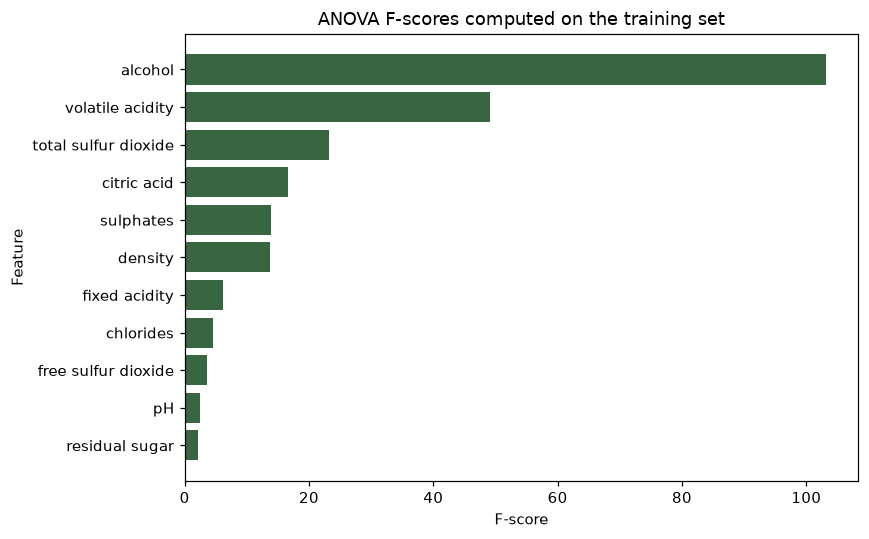

已保存: /Users/wanwanzhu/yolo/work/b_red_wine_figures/03_feature_selection_scores.png


In [7]:
# SelectKBest 只在训练集上拟合，下面的 F 分数不会使用测试集。
selector_for_analysis = SelectKBest(score_func=f_classif, k="all")
selector_for_analysis.fit(X_train, y_train)

feature_scores = pd.DataFrame(
    {
        "feature": FEATURE_NAMES,
        "f_score": selector_for_analysis.scores_,
        "p_value": selector_for_analysis.pvalues_,
    }
).sort_values("f_score", ascending=False)
feature_scores["rank"] = np.arange(1, len(feature_scores) + 1)
display(feature_scores.round({"f_score": 4, "p_value": 6}))

fig, ax = plt.subplots(figsize=(8, 5))
plot_scores = feature_scores.sort_values("f_score")
ax.barh(plot_scores["feature"], plot_scores["f_score"], color="#386641")
ax.set_title("ANOVA F-scores computed on the training set")
ax.set_xlabel("F-score")
ax.set_ylabel("Feature")
fig.tight_layout()
score_fig = FIGURE_DIR / "03_feature_selection_scores.png"
fig.savefig(score_fig, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"已保存: {score_fig}")

标准化后的 11 个特征达到 95% 累计解释方差需要 9 个主成分。
后续模型比较中的 PCA 管道会在每个交叉验证折内重新拟合，避免折间信息泄漏。


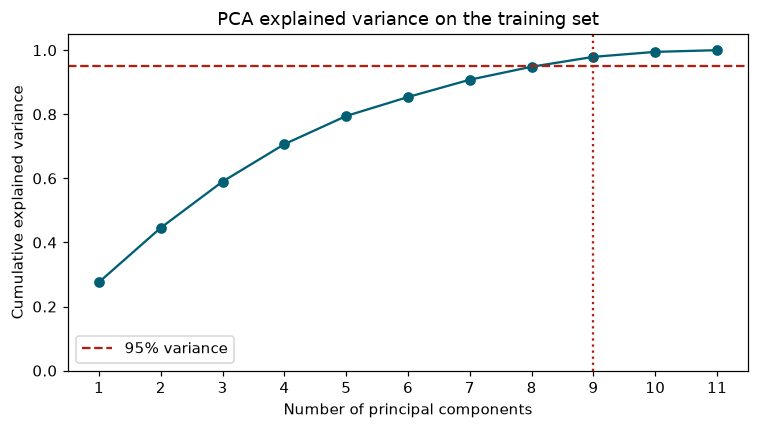

已保存: /Users/wanwanzhu/yolo/work/b_red_wine_figures/04_pca_explained_variance.png


In [8]:
# PCA 是另一种特征提取方式；标准化和 PCA 也只使用训练集拟合。
train_scaler_for_pca = StandardScaler()
X_train_scaled = train_scaler_for_pca.fit_transform(X_train)
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)

print(f"标准化后的 11 个特征达到 95% 累计解释方差需要 {n_components_95} 个主成分。")
print("后续模型比较中的 PCA 管道会在每个交叉验证折内重新拟合，避免折间信息泄漏。")

fig, ax = plt.subplots(figsize=(7, 4))
components = np.arange(1, len(cumulative_variance) + 1)
ax.plot(components, cumulative_variance, marker="o", color="#005f73")
ax.axhline(0.95, color="#ae2012", linestyle="--", label="95% variance")
ax.axvline(n_components_95, color="#ae2012", linestyle=":")
ax.set_xticks(components)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained variance on the training set")
ax.legend()
fig.tight_layout()
pca_fig = FIGURE_DIR / "04_pca_explained_variance.png"
fig.savefig(pca_fig, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"已保存: {pca_fig}")

## 5. 多模型比较：训练集内 5 折分层交叉验证

In [9]:
SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
}
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_models = {
    "Majority baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": Pipeline(
        [
            ("scale", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Logistic + SelectKBest": Pipeline(
        [
            ("scale", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=8)),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "PCA + Logistic regression": Pipeline(
        [
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "SVC (RBF)": Pipeline(
        [
            ("scale", StandardScaler()),
            ("clf", SVC(C=2, class_weight="balanced")),
        ]
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Extra trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Histogram gradient boosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

cv_rows = []
cv_fold_results = {}
for model_name, model in candidate_models.items():
    fold_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=CV,
        scoring=SCORING,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    cv_fold_results[model_name] = fold_scores
    cv_rows.append(
        {
            "model": model_name,
            "accuracy": fold_scores["test_accuracy"].mean(),
            "balanced_accuracy": fold_scores["test_balanced_accuracy"].mean(),
            "macro_f1": fold_scores["test_macro_f1"].mean(),
            "weighted_f1": fold_scores["test_weighted_f1"].mean(),
            "mae": -fold_scores["test_mae"].mean(),
            "macro_f1_std": fold_scores["test_macro_f1"].std(ddof=1),
        }
    )

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(["macro_f1", "balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)
display(cv_results.round(4))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,mae,macro_f1_std
0,Histogram gradient boosting,0.6862,0.3753,0.3875,0.6719,0.3523,0.0368
1,Extra trees,0.7092,0.3754,0.3839,0.6921,0.3254,0.0323
2,Random forest,0.7077,0.3708,0.3832,0.6891,0.3238,0.0448
3,SVC (RBF),0.5323,0.3647,0.3233,0.5487,0.5531,0.0365
4,Logistic regression,0.4277,0.3897,0.2827,0.4696,0.7685,0.0517
5,PCA + Logistic regression,0.4154,0.4228,0.2775,0.4620,0.8138,0.0433
6,Logistic + SelectKBest,0.3946,0.4505,0.2641,0.4392,0.8415,0.0271
7,Majority baseline,0.4200,0.1667,0.0986,0.2485,0.7446,0.0003


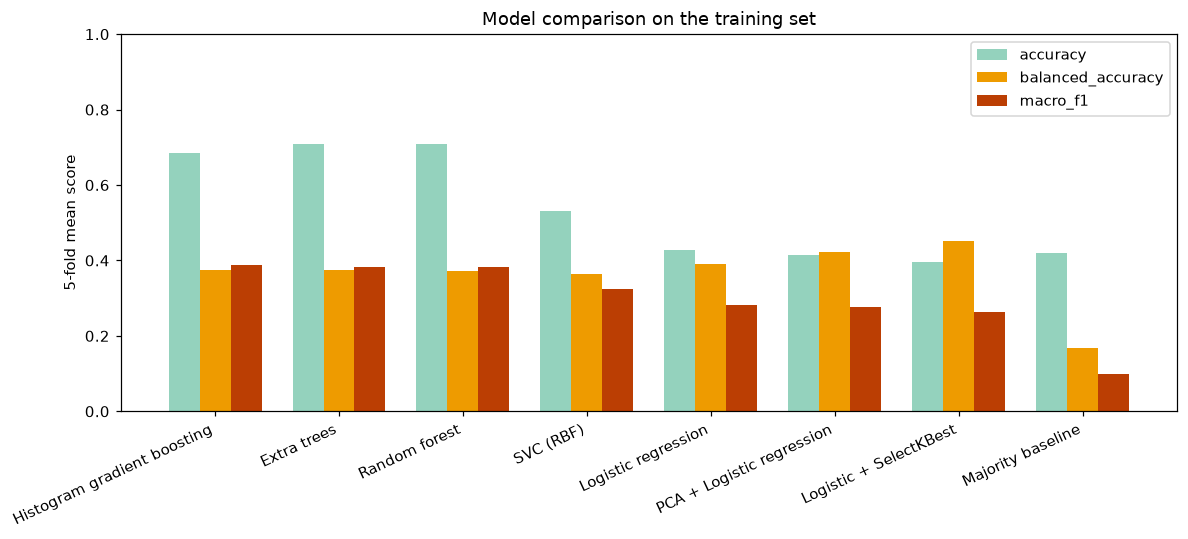

已保存: /Users/wanwanzhu/yolo/work/b_red_wine_figures/05_model_cv_comparison.png
模型选择主指标: macro-F1；测试集仍未参与上述比较。


In [10]:
plot_metrics = cv_results.set_index("model")[["accuracy", "balanced_accuracy", "macro_f1"]]
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_metrics))
bar_width = 0.25
for offset, metric, color in [
    (-bar_width, "accuracy", "#94d2bd"),
    (0, "balanced_accuracy", "#ee9b00"),
    (bar_width, "macro_f1", "#bb3e03"),
]:
    ax.bar(x + offset, plot_metrics[metric], width=bar_width, label=metric, color=color)
ax.set_xticks(x, plot_metrics.index, rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("5-fold mean score")
ax.set_title("Model comparison on the training set")
ax.legend()
fig.tight_layout()
model_fig = FIGURE_DIR / "05_model_cv_comparison.png"
fig.savefig(model_fig, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"已保存: {model_fig}")
print("模型选择主指标: macro-F1；测试集仍未参与上述比较。")

## 6. 超参数优化：ExtraTrees + SelectKBest

基线比较中，树模型的 accuracy 和 weighted-F1 较高，ExtraTrees 与 Histogram Gradient Boosting 的 macro-F1 接近。为同时完成特征选择、非线性建模和特征重要性分析，本实验进一步优化 ExtraTrees + SelectKBest；最终参数仍严格以训练集 5 折交叉验证的 macro-F1 选择。

In [11]:
# 将特征选择放进 Pipeline，保证每一个 CV 折都只用该折的训练部分拟合选择器。
tuned_pipeline = Pipeline(
    [
        ("select", SelectKBest(score_func=f_classif)),
        (
            "clf",
            ExtraTreesClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

param_grid = {
    "select__k": [8, 10, 11],
    "clf__n_estimators": [200],
    "clf__max_depth": [None, 16],
    "clf__min_samples_leaf": [2, 4],
    "clf__max_features": ["sqrt", 0.8],
    "clf__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    scoring=SCORING,
    refit="macro_f1",
    cv=CV,
    n_jobs=1,
    return_train_score=False,
    error_score="raise",
)
grid_search.fit(X_train, y_train)

print(f"网格组合数量: {len(grid_search.cv_results_['params'])}")
print(f"最优 5 折 macro-F1: {grid_search.best_score_:.4f}")
print("最优参数:")
for parameter, value in grid_search.best_params_.items():
    print(f"  {parameter}: {value}")

search_results = pd.DataFrame(grid_search.cv_results_)
search_results["cv_mae"] = -search_results["mean_test_mae"]
top_search_results = (
    search_results.sort_values("rank_test_macro_f1")
    [
        [
            "param_select__k",
            "param_clf__n_estimators",
            "param_clf__max_depth",
            "param_clf__min_samples_leaf",
            "param_clf__max_features",
            "param_clf__class_weight",
            "mean_test_macro_f1",
            "std_test_macro_f1",
            "mean_test_balanced_accuracy",
            "mean_test_accuracy",
            "mean_test_weighted_f1",
            "cv_mae",
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)
display(top_search_results.round(4))

网格组合数量: 48
最优 5 折 macro-F1: 0.4529
最优参数:
  clf__class_weight: balanced
  clf__max_depth: 16
  clf__max_features: 0.8
  clf__min_samples_leaf: 4
  clf__n_estimators: 200
  select__k: 10


,param_select__k,param_clf__n_estimators,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__max_features,param_clf__class_weight,mean_test_macro_f1,std_test_macro_f1,mean_test_balanced_accuracy,mean_test_accuracy,mean_test_weighted_f1,cv_mae
0,10,200,16,4,0.8,balanced,0.4529,0.0457,0.4874,0.6600,0.6634,0.3985
1,11,200,None,4,0.8,balanced,0.4395,0.0668,0.4635,0.6515,0.6548,0.4023
2,8,200,None,2,0.8,balanced,0.4326,0.0765,0.4420,0.6885,0.6833,0.3523
3,10,200,None,4,0.8,balanced,0.4300,0.0404,0.4473,0.6538,0.6571,0.4038
4,11,200,16,4,0.8,balanced,0.4286,0.0695,0.4597,0.6492,0.6517,0.4062
5,8,200,None,4,0.8,balanced,0.4205,0.0433,0.4485,0.6377,0.6418,0.4223
6,8,200,16,2,0.8,balanced,0.4203,0.0634,0.4146,0.6938,0.6888,0.3492
7,11,200,16,2,sqrt,balanced,0.4161,0.0598,0.4120,0.6992,0.6913,0.3377
8,8,200,16,4,0.8,balanced,0.4098,0.0426,0.4422,0.6238,0.6285,0.4362
9,8,200,None,2,sqrt,balanced,0.4066,0.0461,0.4070,0.6708,0.6667,0.3738


## 7. 在完整训练集上重训并评估测试集

In [12]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

selected_mask = best_model.named_steps["select"].get_support()
selected_features = X_train.columns[selected_mask].tolist()
print(f"最终模型: {best_model}")
print(f"最终选择的特征数: {len(selected_features)} / {len(FEATURE_NAMES)}")
print("最终选择的特征:", selected_features)

y_pred = best_model.predict(X_test)
test_probability = best_model.predict_proba(X_test)
class_order = best_model.named_steps["clf"].classes_
y_pred_by_argmax = class_order[np.argmax(test_probability, axis=1)]
assert np.array_equal(y_pred, y_pred_by_argmax), "predict 与 predict_proba + argmax 的结果不一致"

test_metrics = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "mae",
        ],
        "test_value": [
            accuracy_score(y_test, y_pred),
            balanced_accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro", zero_division=0),
            f1_score(y_test, y_pred, average="weighted", zero_division=0),
            mean_absolute_error(y_test, y_pred),
        ],
    }
)
display(test_metrics.round(4))

print("测试集分类报告:")
test_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        labels=sorted(df[TARGET].unique()),
        output_dict=True,
        zero_division=0,
    )
).T
display(test_report.round(4))

最终模型: Pipeline(steps=[('select', SelectKBest()),
                ('clf',
                 ExtraTreesClassifier(class_weight='balanced', max_depth=16,
                                      max_features=0.8, min_samples_leaf=4,
                                      n_estimators=200, n_jobs=1,
                                      random_state=42))])
最终选择的特征数: 10 / 11
最终选择的特征: ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


,metric,test_value
0,accuracy,0.5518
1,balanced_accuracy,0.3006
2,macro_f1,0.2776
3,weighted_f1,0.5634
4,mae,0.5318


测试集分类报告:


,precision,recall,f1-score,support
3,0.0000,0.0000,0.0000,4.0000
4,0.1053,0.2000,0.1379,10.0000
5,0.6953,0.6593,0.6768,135.0000
6,0.5909,0.5159,0.5508,126.0000
7,0.2308,0.4286,0.3000,21.0000
8,0.0000,0.0000,0.0000,3.0000
accuracy,0.5518,0.5518,0.5518,0.5518
macro avg,0.2704,0.3006,0.2776,299.0000
weighted avg,0.5827,0.5518,0.5634,299.0000


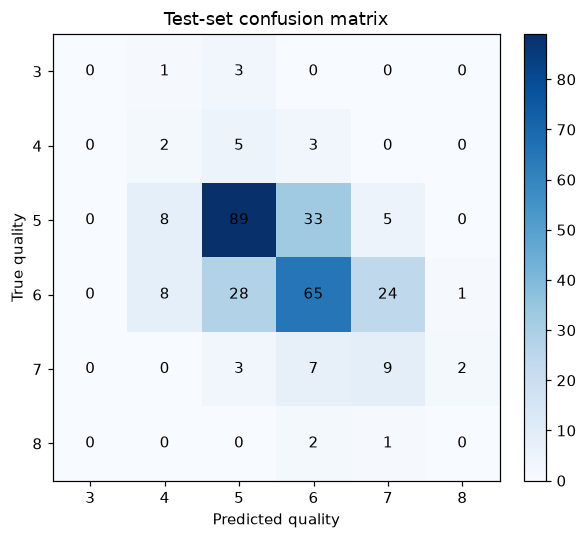

已保存: /Users/wanwanzhu/yolo/work/b_red_wine_figures/06_test_confusion_matrix.png


In [13]:
labels = sorted(df[TARGET].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels)
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("Predicted quality")
ax.set_ylabel("True quality")
ax.set_title("Test-set confusion matrix")
for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        ax.text(column, row, int(cm[row, column]), ha="center", va="center")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
cm_fig = FIGURE_DIR / "06_test_confusion_matrix.png"
fig.savefig(cm_fig, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"已保存: {cm_fig}")

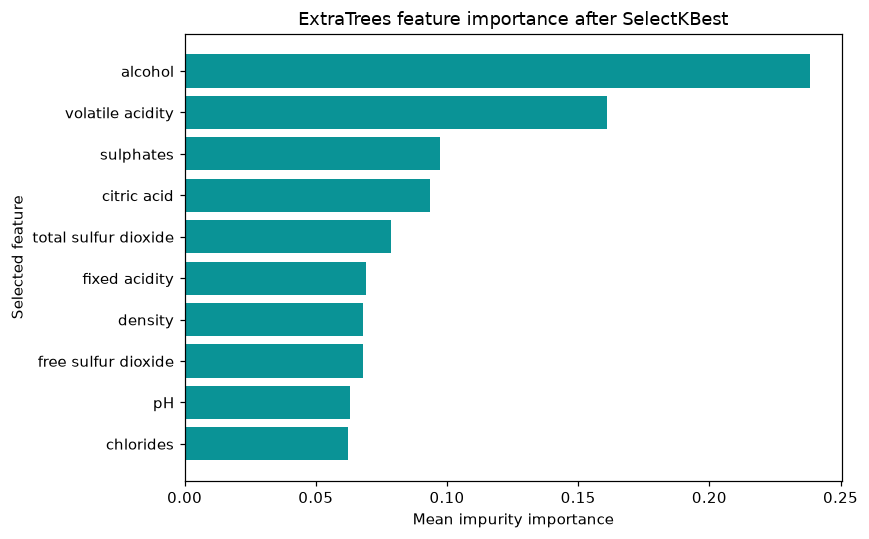

,feature,importance
9,alcohol,0.2385
1,volatile acidity,0.1610
8,sulphates,0.0973
2,citric acid,0.0935
5,total sulfur dioxide,0.0788
0,fixed acidity,0.0693
6,density,0.0681
4,free sulfur dioxide,0.0681
7,pH,0.0631
3,chlorides,0.0625


已保存: /Users/wanwanzhu/yolo/work/b_red_wine_figures/07_final_feature_importance.png


In [14]:
feature_importance = pd.DataFrame(
    {
        "feature": selected_features,
        "importance": best_model.named_steps["clf"].feature_importances_,
    }
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feature_importance["feature"], feature_importance["importance"], color="#0a9396")
ax.set_title("ExtraTrees feature importance after SelectKBest")
ax.set_xlabel("Mean impurity importance")
ax.set_ylabel("Selected feature")
fig.tight_layout()
importance_fig = FIGURE_DIR / "07_final_feature_importance.png"
fig.savefig(importance_fig, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
display(feature_importance.sort_values("importance", ascending=False).round(4))
print(f"已保存: {importance_fig}")

In [15]:
prediction_output = test_df[FEATURE_NAMES].copy()
prediction_output.insert(0, "original_row", test_df.index)
prediction_output["actual_quality"] = y_test.to_numpy()
prediction_output["predicted_quality"] = y_pred
prediction_output["max_probability"] = test_probability.max(axis=1)
prediction_output["correct"] = prediction_output["actual_quality"] == prediction_output["predicted_quality"]

prediction_path = OUTPUT_DIR / "red_wine_test_predictions.csv"
prediction_output.to_csv(prediction_path, index=False)

print(f"测试集预测条数: {len(prediction_output)}")
print(f"预测结果文件: {prediction_path}")
display(prediction_output.head(10).round(4))

测试集预测条数: 299
预测结果文件: /Users/wanwanzhu/yolo/work/b_red_wine_outputs/red_wine_test_predictions.csv


,original_row,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,actual_quality,predicted_quality,max_probability,correct
1300,1300,5.2,0.645,0.00,2.15,0.080,15.0,28.0,0.9944,3.78,0.61,12.5,6,7,0.3897,False
1301,1301,6.7,0.860,0.07,2.00,0.100,20.0,57.0,0.9960,3.60,0.74,11.7,6,7,0.3010,False
1302,1302,9.1,0.370,0.32,2.10,0.064,4.0,15.0,0.9958,3.30,0.80,11.2,6,7,0.5690,False
1303,1303,8.0,0.280,0.44,1.80,0.081,28.0,68.0,0.9950,3.36,0.66,11.2,5,6,0.5027,False
1304,1304,7.6,0.790,0.21,2.30,0.087,21.0,68.0,0.9955,3.12,0.44,9.2,5,5,0.7228,True
1305,1305,7.5,0.610,0.26,1.90,0.073,24.0,88.0,0.9961,3.30,0.53,9.8,5,5,0.6430,True
1306,1306,9.7,0.690,0.32,2.50,0.088,22.0,91.0,0.9979,3.29,0.62,10.1,5,5,0.5846,True
1307,1307,6.8,0.680,0.09,3.90,0.068,15.0,29.0,0.9952,3.41,0.52,11.1,4,6,0.5364,False
1308,1308,9.7,0.690,0.32,2.50,0.088,22.0,91.0,0.9979,3.29,0.62,10.1,5,5,0.5846,True
1309,1309,7.0,0.620,0.10,1.40,0.071,27.0,63.0,0.9960,3.28,0.61,9.2,5,5,0.6766,True


## 8. 实验结果小结

- 训练集和测试集严格按题目给出的样本顺序切分，测试集没有参与交叉验证和超参数选择。
- 所有需要拟合的预处理步骤都放在交叉验证管道内；最终模型只用完整训练集拟合一次后预测测试集。
- predict 与 predict_proba 后对类别概率使用 argmax 得到的结果已在代码中核对一致。
- 由于质量标签极不均衡，测试集结果需要结合每个等级的 precision、recall、F1 和混淆矩阵理解，不能只看 accuracy。
- 生成的图表位于 work/b_red_wine_figures/，299 条测试集预测位于 work/b_red_wine_outputs/red_wine_test_predictions.csv。